In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

datapath = Path("datasets") / "lifesat"
datapath.mkdir(parents=True, exist_ok=True)

oecd_bli = pd.read_csv(datapath / "oecd_bli.csv")
gdp_per_capita = pd.read_csv(datapath / "gdp_per_capita.csv")

In [2]:
gdp_year = 2020
gdppc_col = "GDP per capita (USD)"
lifesat_col = "Life satisfaction"

gdp_per_capita = gdp_per_capita[gdp_per_capita["Year"] == gdp_year]
gdp_per_capita = gdp_per_capita.drop(["Code", "Year"], axis=1)
gdp_per_capita.columns = ["Country", gdppc_col]
gdp_per_capita.set_index("Country", inplace=True)

gdp_per_capita.head()

,GDP per capita (USD)
Country,
Afghanistan,1978.961579
Africa Eastern and Southern,3387.594670
Africa Western and Central,4003.158913
Albania,13295.410885
Algeria,10681.679297


In [3]:
oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")

oecd_bli.head()

Indicator,Air pollution,Dwellings without basic facilities,Educational attainment,Employees working very long hours,Employment rate,Feeling safe walking alone at night,Homicide rate,Household net adjusted disposable income,Household net wealth,Housing expenditure,...,Personal earnings,Quality of support network,Rooms per person,Self-reported health,Stakeholder engagement for developing regulations,Student skills,Time devoted to leisure and personal care,Voter turnout,Water quality,Years in education
Country,,,,,,,,,,,,,,,,,,,,,
Australia,5.0,NaN,81.0,13.04,73.0,63.5,1.1,32759.0,427064.0,20.0,...,49126.0,95.0,NaN,85.0,2.7,502.0,14.35,91.0,93.0,21.0
Austria,16.0,0.9,85.0,6.66,72.0,80.6,0.5,33541.0,308325.0,21.0,...,50349.0,92.0,1.6,70.0,1.3,492.0,14.55,80.0,92.0,17.0
Belgium,15.0,1.9,77.0,4.75,63.0,70.1,1.0,30364.0,386006.0,21.0,...,49675.0,91.0,2.2,74.0,2.0,503.0,15.70,89.0,84.0,19.3
Brazil,10.0,6.7,49.0,7.13,61.0,35.6,26.7,NaN,NaN,NaN,...,NaN,90.0,NaN,NaN,2.2,395.0,NaN,79.0,73.0,16.2
Canada,7.0,0.2,91.0,3.69,73.0,82.2,1.3,30854.0,423849.0,22.0,...,47622.0,93.0,2.6,88.0,2.9,523.0,14.56,68.0,91.0,17.3


In [4]:
full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                              left_index=True, right_index=True)
full_country_stats.sort_values(by=gdppc_col, inplace=True)
full_country_stats = full_country_stats[[gdppc_col, lifesat_col]]

full_country_stats.head()

,GDP per capita (USD),Life satisfaction
Country,,
South Africa,11466.189672,4.7
Colombia,13441.492952,6.3
Brazil,14063.982505,6.4
Mexico,17887.750736,6.5
Chile,23324.524751,6.5


In [5]:
full_country_stats.to_csv(datapath / "lifesat_full.csv")

In [6]:
min_gdp = 23500
max_gdp = 62500

country_stats = full_country_stats[(full_country_stats[gdppc_col] >= min_gdp) &
                                   (full_country_stats[gdppc_col] <= max_gdp)]
country_stats.head()

,GDP per capita (USD),Life satisfaction
Country,,
Russia,26456.387938,5.8
Greece,27287.083401,5.4
Turkey,28384.987785,5.5
Latvia,29932.493910,5.9
Hungary,31007.768407,5.6


In [7]:
country_stats.to_csv(datapath / "lifesat.csv")

(4.0, 9.0)

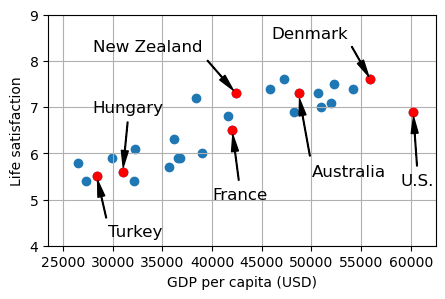

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(
    country_stats[gdppc_col],
    country_stats[lifesat_col]
)

ax.grid(True)
ax.set_xlabel(gdppc_col)
ax.set_ylabel(lifesat_col)

min_life_sat = 4
max_life_sat = 9

position_text = {
    "Turkey": (29_500, 4.2),
    "Hungary": (28_000, 6.9),
    "France": (40_000, 5),
    "New Zealand": (28_000, 8.2),
    "Australia": (50_000, 5.5),
    "United States": (59_000, 5.3),
    "Denmark": (46_000, 8.5)
}

for country, pos_text in position_text.items():
    x = country_stats.loc[country, gdppc_col]
    y = country_stats.loc[country, lifesat_col]

    label = "U.S." if country == "United States" else country

    ax.annotate(
        label,
        xy=(x, y),
        xytext=pos_text,
        fontsize=12,
        arrowprops=dict(
            facecolor="black",
            width=0.5,
            shrink=0.08,
            headwidth=5
        )
    )

    ax.plot(x, y, "ro")
    
ax.set_xlim(min_gdp, max_gdp)
ax.set_ylim(min_life_sat, max_life_sat)




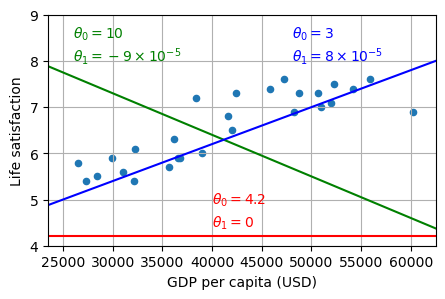

In [9]:
country_stats.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x=gdppc_col, y=lifesat_col)

X = np.linspace(min_gdp, max_gdp, 1000)

w1, w2 = 4.2, 0
plt.plot(X, w1 + w2 * 1e-5 * X, "r")
plt.text(40_000, 4.9, fr"$\theta_0 = {w1}$", color="r")
plt.text(40_000, 4.4, fr"$\theta_1 = {w2}$", color="r")

w1, w2 = 10, -9
plt.plot(X, w1 + w2 * 1e-5 * X, "g")
plt.text(26_000, 8.5, fr"$\theta_0 = {w1}$", color="g")
plt.text(26_000, 8.0, fr"$\theta_1 = {w2} \times 10^{{-5}}$", color="g")

w1, w2 = 3, 8
plt.plot(X, w1 + w2 * 1e-5 * X, "b")
plt.text(48_000, 8.5, fr"$\theta_0 = {w1}$", color="b")
plt.text(48_000, 8.0, fr"$\theta_1 = {w2} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])


plt.show()

In [10]:
from sklearn import linear_model

X_sample = country_stats[[gdppc_col]].values
y_sample = country_stats[[lifesat_col]].values

lin1 = linear_model.LinearRegression()
lin1.fit(X_sample, y_sample)

t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]
print(f"θ_0={t0:.2f}, θ_1={t1:.2e}")

θ_0=3.75, θ_1=6.78e-05


In [11]:
cyprus_gdp_per_capita = gdp_per_capita[gdppc_col].loc["Cyprus"]
cyprus_gdp_per_capita

37655.1803457421

In [12]:
lin1.predict([[cyprus_gdp_per_capita]])

array([[6.30165633]])

In [13]:
import torch

# Entrada: una muestra, una característica
x = torch.tensor([[cyprus_gdp_per_capita]], dtype=torch.float32)

# Parámetros aprendidos
theta0 = torch.tensor([t0])
theta1 = torch.tensor([t1])

# Predicción
y_hat = theta0 + theta1 * x

y_hat.item()

6.301656288116485

In [14]:
#PIB de Chipre (dato conocido)
cyprus_gdp_per_capita = gdp_per_capita.loc["Cyprus", gdppc_col]

In [15]:
#Distancias en PIB (todos los países)
distances = (gdp_per_capita[gdppc_col] - cyprus_gdp_per_capita).abs()

In [16]:
#Filtrar solo países con satisfacción conocida
valid_distances = distances.loc[distances.index.intersection(country_stats.index)]

In [17]:
# Los 3 países más cercanos
closest_3 = valid_distances.sort_values().head(3)
closest_3
#Imprimir PIB + satisfacción
for country in closest_3.index:
    gdp = gdp_per_capita.loc[country, gdppc_col]
    life_sat = country_stats.loc[country, lifesat_col]

    print(
        f"{country}: "
        f"PIB per cápita = {gdp:,.0f} USD, "
        f"Satisfacción = {life_sat:.2f}"
    )

Israel: PIB per cápita = 38,341 USD, Satisfacción = 7.20
Lithuania: PIB per cápita = 36,732 USD, Satisfacción = 5.90
Slovenia: PIB per cápita = 36,548 USD, Satisfacción = 5.90
